Here we are trying to determine the Mpeak bin to use for MultiCAM application on the hydro-only experiment, where we don't perform any matching just use the dark matter part of the hydro simulation and predict the hydro/galaxy parameters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, TNG_H


In [3]:
# stellar mass of 100 particles (Msun / h) like phil's data 
# this is the minimum stellar mass bin we should use for all experiments and to figure out SHMR
np.log10(1.4e6 * 100 / TNG_H)

np.float64(8.315282843369626)

In [4]:
# read tree data 
with open("../../data/out-trees-tng100-bar.npz", 'rb') as fp:
    hydro_data = np.load(fp)
    _mpeak = hydro_data['mpeak']
    _stellar_mass =hydro_data['stellar_mass']

_mpeak.shape, _stellar_mass.shape

((101431,), (101431,))

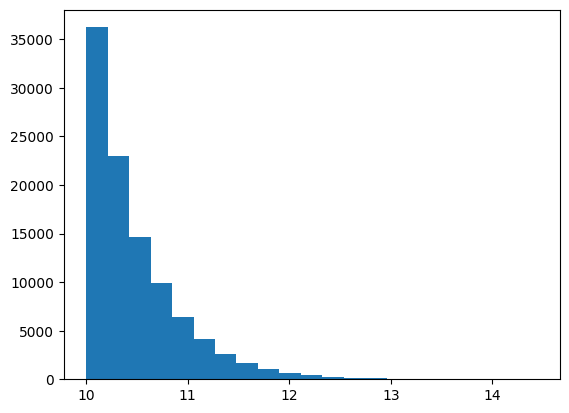

In [5]:
mask = _mpeak > 0
plt.hist(np.log10(_mpeak[mask]),bins=21); # already in M_sun /h units

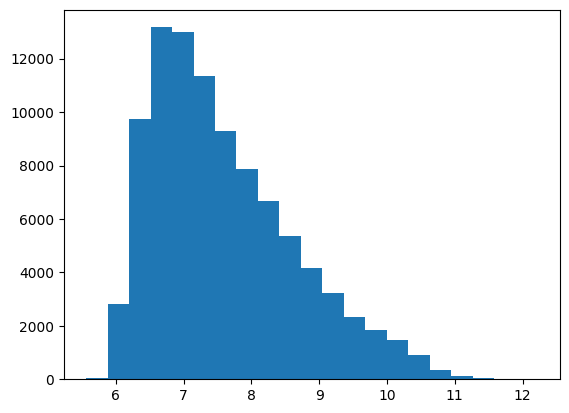

In [6]:
mask = _stellar_mass > 0
plt.hist(np.log10(_stellar_mass[mask]),bins=21);

In [7]:
star_mask = (_stellar_mass > 0) & (_mpeak > 0)

log_smass = np.log10(_stellar_mass[star_mask])
log_mpeak = np.log10(_mpeak[star_mask])

log_smass.shape, log_mpeak.shape

((93851,), (93851,))

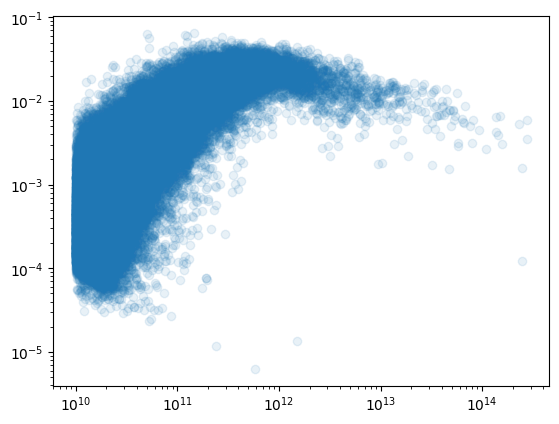

In [8]:
# does this look more like the stellar to halo mass relation??
plt.plot(10**log_mpeak, (10**log_smass / 10**log_mpeak), 'o', alpha=0.1)
plt.yscale('log')
plt.xscale('log')
# more reasonable???

In [9]:
mask1 = (log_smass > 9.5) & (log_smass < 10.2) 
 # need to avoid unresolved objects ALSO in the SHMH scatter
sum(mask1)

np.int64(4055)

(11.079, 12.109)
Extent: 1.030


Text(0.5, 0, 'M_peak')

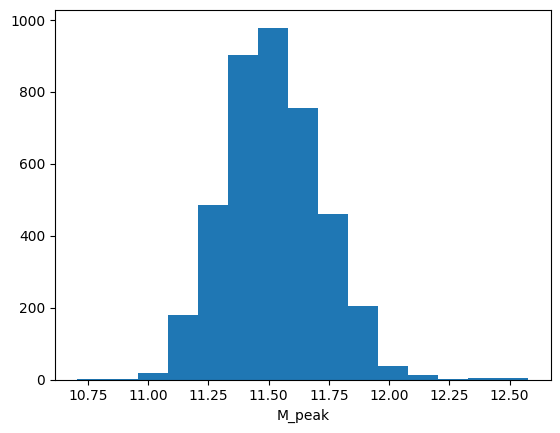

In [10]:
x = log_mpeak[mask1]
plt.hist(x, bins=15);

q1 = np.quantile(x, 0.005)
q2 = np.quantile(x, 0.995)
print(f"({q1:.3f}, {q2:.3f})")
print(f"Extent: {q2 - q1:.3f}")
plt.xlabel("M_peak")

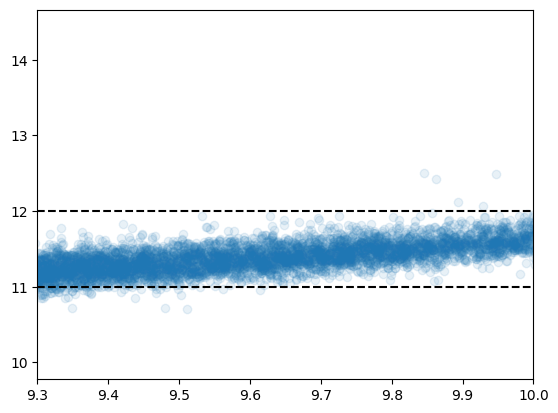

In [11]:
plt.scatter(log_smass, log_mpeak,  alpha=0.1)
plt.xlim(9.3, 10.0)
plt.axhline(11, c='k', ls='--')
plt.axhline(12, c='k', ls='--')

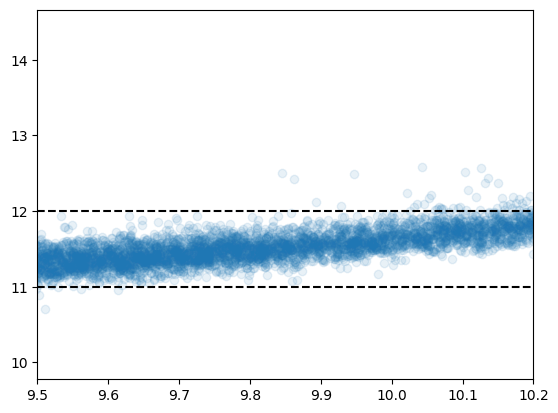

In [12]:
# this one is Kuan's sugestion which is clearly better keeping the mpeak mass bin to be (11, 12)
plt.scatter(log_smass, log_mpeak,  alpha=0.1)
plt.xlim(9.5, 10.2)
plt.axhline(11, c='k', ls='--')
plt.axhline(12, c='k', ls='--')

In [ ]:
# mask = (log_mpeak > 11) & (log_mpeak < 12) 
#  # need to avoid unresolved objects ALSO in the SHMH scatter
# sum((log_smass[mask] < 9.3) | (log_smass[mask] > 10.0))

np.int64(6607)

In [17]:
mask = (log_smass > 9.3 ) & ( log_smass < 10.0)
sum( (log_mpeak[mask]  < 11.0) | (log_mpeak[mask]  > 12.0))

np.int64(68)

In [24]:
mask = (log_smass > 9.5 ) & ( log_smass < 10.2)
sum( (log_mpeak[mask]  < 11.0) | (log_mpeak[mask]  > 12.0)), sum(mask)

(np.int64(53), np.int64(4055))